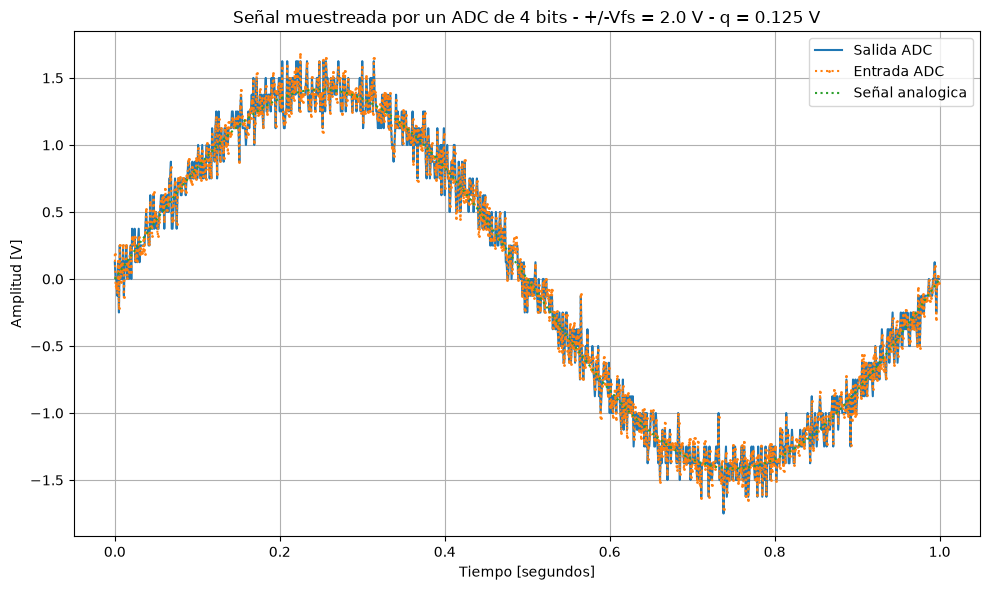

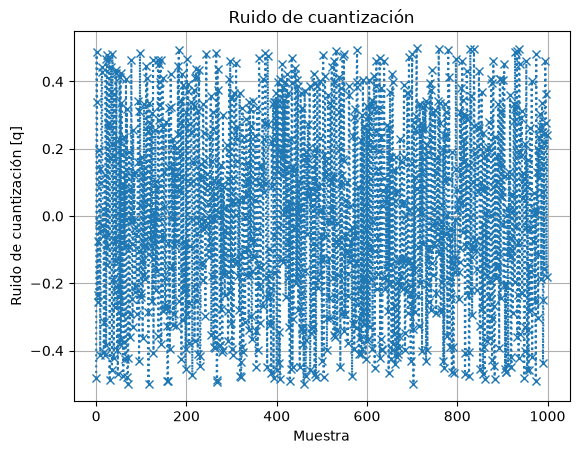

Media del ruido de cuantizacion:
7.11523530738793e-05
Varianza del ruido de cuantizacion:
0.001257244186891236
q^2/12:
0.0013020833333333333


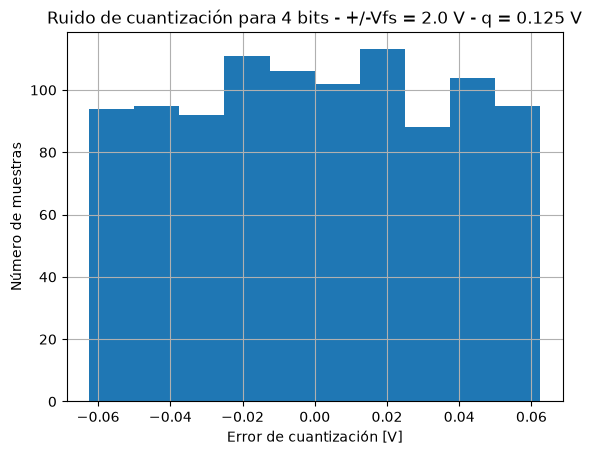

Estadístico D = 0.021855877673090995
p-valor = 0.7173356095846225
No rechazamos H0: el ruido de cuantizacion es compatible con una distribucion uniforme.

Piso medio del ruido analogico:
-46.00148630677013 dB
Piso medio del ruido de cuantizacion:
-55.98738257716907 dB


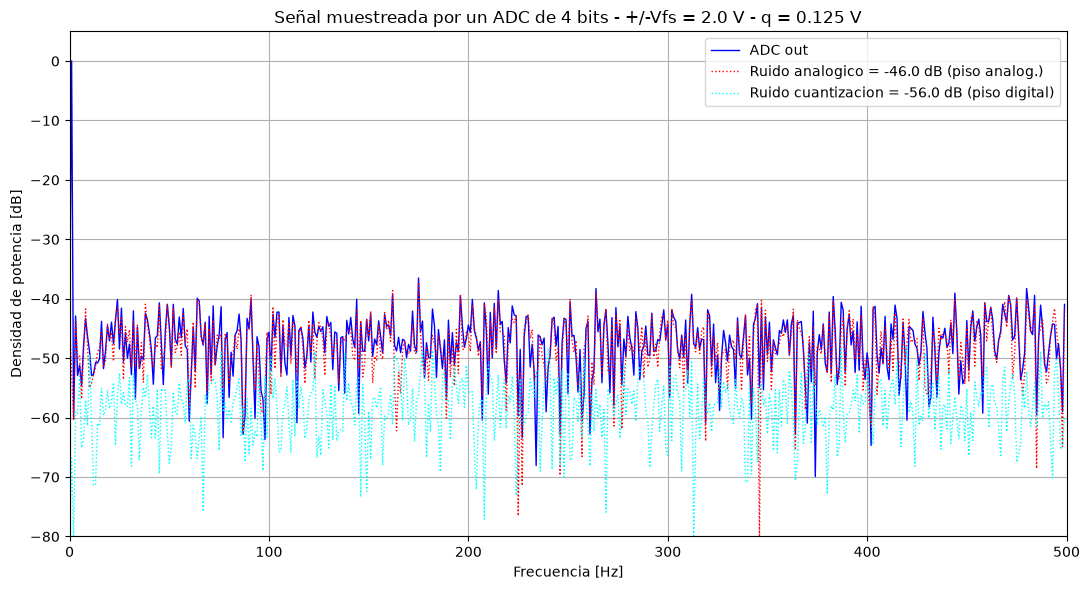

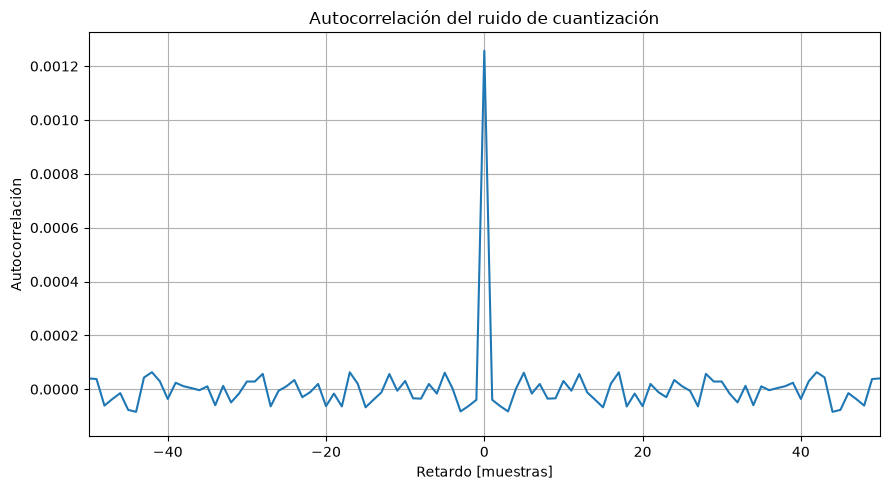


Autocorrelacion en retardo cero:
0.0012572492495485843
Potencia teorica q^2/12:
0.0013020833333333333


In [1]:
# -*- coding: utf-8 -*-
"""
Created on Thu Sep  2 18:05:58 2026

@author: Daniela Rolando
"""


#%% IMPORTACION DE MODULOS

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


#%% DEFINICION CTES

fs = 1000            # Frecuencia de muestreo [Hz]
N = 1000             # Cantidad de muestras

Vmax = np.sqrt(2)    # Amplitud maxima de la senoide
dc = 0               # Offset
ff = 1               # Frecuencia de la senoide [Hz]
ph = 0               # Fase [rad]

Psen = 1             # Potencia media de la senoide [W]
ur = 0               # Media del ruido

delta_f = fs/N


# ADC

B = 4                # Bits
Vfs = 2              # Rango +/- Vfs [V]

# En la grafica de clase para B = 4 y +/-2V se utiliza q = 0.125 V
qq = 0.125

# Factor de potencia del ruido
kn = 10


# Potencia teorica del ruido de cuantizacion
Pq = qq**2 / 12

# Potencia del ruido analogico
Pn = kn * Pq


#%% FUNCIONES


# Generador de señal senoidal

def gen_sin(Vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs):

    # Genero un vector de valores de 0 a N/fs segundos
    # a intervalos de 1/fs

    tt = np.arange(0, stop=nn/fs, step=1/fs)

    # Genero un vector con los valores de la señal senoidal

    xx = dc + Vmax * np.sin(2 * np.pi * ff * tt + ph)

    return tt, xx



# Generador de ruido

def gen_noise(Pn=Pn, ur=ur, nn=N):

    # La potencia del ruido es igual a su varianza
    # Pn = sigma^2

    desv_est_r = np.sqrt(Pn)

    # Genero ruido gaussiano de media cero

    ruido = np.random.normal(ur, desv_est_r, nn)

    return ruido



#%% MAIN SCRIPT


# Para que al volver a ejecutar el programa obtengamos siempre la misma realizacion de ruido

np.random.seed(1)


# Invoco la funcion generadora de senoides

tt, xx = gen_sin(Vmax, dc, ff, ph, N, fs)


# Invoco la funcion generadora de ruido

ruido = gen_noise(Pn, ur, N)


# Armo manualmente la señal ruidosa
# Esta es la señal que entra en el ADC

noisy_xx = xx + ruido


# Armo vector de frecuencia
# De 0 hasta aproximadamente Nyquist

frec = np.arange(N//2) * fs/N


plt.close('all')



#%% CUANTIZACION


# Cuantizamos la señal que entra al ADC

xx_q = np.round(noisy_xx / qq) * qq


# Ruido de cuantizacion

nq = xx_q - noisy_xx



#%% GRAFICA TEMPORAL


plt.figure(figsize=(10, 6))

plt.plot(tt, xx_q,
         label='Salida ADC')

plt.plot(tt, noisy_xx, ':',
         marker='.',
         markersize=2,
         label='Entrada ADC')

plt.plot(tt, xx, ':',
         label='Señal analogica')


plt.title('Señal muestreada por un ADC de 4 bits - +/-Vfs = 2.0 V - q = 0.125 V')

plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()



#%% RUIDO DE CUANTIZACION


plt.figure()

plt.plot(nq/qq, ':x')

plt.title('Ruido de cuantización')

plt.xlabel('Muestra')
plt.ylabel('Ruido de cuantización [q]')

plt.grid(True)

plt.show()


# El ruido de cuantizacion tiene que estar aproximadamente entre -q/2 y +q/2



#%% COMPROBACION DEL RUIDO DE CUANTIZACION


# Comprobamos el valor medio

media_nq = np.mean(nq)


print("Media del ruido de cuantizacion:")
print(media_nq)



# Comprobamos la varianza

var_nq = np.var(nq)


# Valor teorico de la varianza

var_teorica = qq**2 / 12


print("Varianza del ruido de cuantizacion:")
print(var_nq)

print("q^2/12:")
print(var_teorica)



#%% HISTOGRAMA DEL RUIDO DE CUANTIZACION


# Utilizamos el histograma para comprobar aproximadamente que el ruido sigue una distribucion uniforme


plt.figure()

plt.hist(nq, bins=10, density=False)

plt.title('Ruido de cuantización para 4 bits - +/-Vfs = 2.0 V - q = 0.125 V')

plt.xlabel('Error de cuantización [V]')
plt.ylabel('Número de muestras')

plt.grid(True)

plt.show()



#%% TEST DE UNIFORMIDAD


# Test de Kolmogorov-Smirnov para comprobar si el ruido de cuantizacion es compatible con una distribucion uniforme


D, pvalor = stats.kstest(
    nq,
    'uniform',
    args=(-qq/2, qq)
)


print("Estadístico D =", D)
print("p-valor =", pvalor)


if pvalor > 0.05:

    print("No rechazamos H0: el ruido de cuantizacion es compatible con una distribucion uniforme.")

else:

    print("Se rechaza H0 para esta realizacion.")




#%% CLASE DÍA 2 DE SEPTIEMBRE

# CONSIGNA: Hacer el espectro de la señal cuantizada y los pisos de ruido hasta Nyquist, y calcular la autocorrelación del ruido de cuantización.

#%% ESPECTROS


# En esta parte añadimos el espectro de la señal cuantizada y de las secuencias de ruido


# FFT de la señal cuantizada

XX_q = (1/N) * np.fft.fft(xx_q)


# FFT del ruido analogico

NN = (1/N) * np.fft.fft(ruido)


# FFT del ruido de cuantizacion

NQ = (1/N) * np.fft.fft(nq)



# Calculamos las potencias espectrales
# Nos quedamos solamente con el intervalo 0 - Nyquist


pot_q = 2 * np.abs(XX_q[:N//2])**2

pot_n = 2 * np.abs(NN[:N//2])**2

pot_nq = 2 * np.abs(NQ[:N//2])**2



# Evitamos logaritmo de cero para que la representacion no se vaya a valores del orden de -300 dB

eps = 1e-20


PSD_q = 10 * np.log10(pot_q + eps)

PSD_n = 10 * np.log10(pot_n + eps)

PSD_nq = 10 * np.log10(pot_nq + eps)



#%% PISOS MEDIOS DE RUIDO


# Calculamos el valor medio de cada piso de ruido
# No utilizamos la componente de continua para hacer la media


piso_analog = 10 * np.log10(
    np.mean(pot_n[1:]) + eps
)


piso_digital = 10 * np.log10(
    np.mean(pot_nq[1:]) + eps
)



print("")
print("Piso medio del ruido analogico:")
print(piso_analog, "dB")

print("Piso medio del ruido de cuantizacion:")
print(piso_digital, "dB")



#%% GRAFICA DEL ESPECTRO


# Representamos solamente:
# azul -> espectro de la salida del ADC
# rojo -> espectro del ruido analogico
# celeste -> espectro del ruido de cuantizacion
# En la leyenda indicamos el valor medio de los pisos de ruido


plt.figure(figsize=(11, 6))


# Azul: salida del ADC

plt.plot(
    frec,
    PSD_q,
    color='blue',
    linewidth=1,
    label='ADC out'
)


# Rojo: ruido analogico

plt.plot(
    frec,
    PSD_n,
    color='red',
    linestyle=':',
    linewidth=1,
    label='Ruido analogico = %.1f dB (piso analog.)' % piso_analog
)


# Celeste: ruido de cuantizacion

plt.plot(
    frec,
    PSD_nq,
    color='cyan',
    linestyle=':',
    linewidth=1,
    label='Ruido cuantizacion = %.1f dB (piso digital)' % piso_digital
)


plt.title(
    'Señal muestreada por un ADC de 4 bits - +/-Vfs = 2.0 V - q = 0.125 V'
)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de potencia [dB]')


# Representamos de 0 hasta Nyquist

plt.xlim(0, fs/2)


# Limitamos el eje vertical para visualizar bien los pisos de ruido

plt.ylim(-80, 5)


plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

#%% AUTOCORRELACION DEL RUIDO DE CUANTIZACION


# Para comprobar que el ruido de cuantizacion es aproximadamente incorrelado calculamos su autocorrelacion


autocorr = np.correlate(nq, nq, mode='full')


# Normalizamos

autocorr = autocorr / N


# Vector de retardos

lags = np.arange(-N + 1, N)



plt.figure(figsize=(9, 5))

plt.plot(lags, autocorr)

plt.title('Autocorrelación del ruido de cuantización')

plt.xlabel('Retardo [muestras]')
plt.ylabel('Autocorrelación')

# Nos acercamos a los retardos proximos a cero para poder observar mejor el comportamiento

plt.xlim(-50, 50)

plt.grid(True)

plt.tight_layout()

plt.show()



#%% VALOR DE LA AUTOCORRELACION EN RETARDO CERO


# En retardo cero deberiamos obtener aproximadamente la potencia del ruido de cuantizacion


R0 = autocorr[N-1]


print("")
print("Autocorrelacion en retardo cero:")
print(R0)

print("Potencia teorica q^2/12:")
print(Pq)



plt.show()